# Prédiction du Stress Environnemental à Ouagadougou
## Système d Alerte Précoce par Télédétection Satellitaire

**Auteur** : Joel  
**Contexte** : Projet Smart City - Formation Data Scientist  
**Objectif** : Prédire les épisodes de Harmattan dangereux 3 jours à l avance

### Sources de données
- Sentinel-5P (ESA) : Absorbing Aerosol Index (AAI)
- MODIS : Land Surface Temperature (LST)
- ERA5 (ECMWF) : Variables météorologiques
- Période : 2018-2025

### Double approche ML
1. **Régression** : Prédire valeur AAI J+3
2. **Classification** : Détecter épisode Harmattan OUI/NON J+3

## 0. Initialisation et Rechargement

Chargement des librairies, du dataset et des modèles sauvegardés.
Cette cellule doit être exécutée en premier à chaque redémarrage de Colab.

In [30]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, f1_score, roc_auc_score,
    classification_report, recall_score, precision_score,
    confusion_matrix, roc_curve
)
from imblearn.over_sampling import SMOTE
import shap
import joblib
import json
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv("/content/drive/MyDrive/Ouaga_Grid/ouaga_dataset_final_ml.csv")

save_dir  = '/content/drive/MyDrive/Ouaga_Grid/models/'
rf_reg    = joblib.load(save_dir + 'rf_regression.pkl')
rf_clf    = joblib.load(save_dir + 'rf_classification.pkl')

with open(save_dir + 'config.json', 'r') as f:
    config = json.load(f)

seuil_optimal = config['seuil_optimal']
features      = config['features']

X     = df[features].dropna()
y_reg = df.loc[X.index, 'AAI_t3']
y_clf = df.loc[X.index, 'harmattan_bin_t3']

split_idx     = int(len(X) * 0.80)
X_train       = X.iloc[:split_idx]
X_test        = X.iloc[split_idx:]
y_reg_train   = y_reg.iloc[:split_idx]
y_reg_test    = y_reg.iloc[split_idx:]
y_clf_train   = y_clf.iloc[:split_idx]
y_clf_test    = y_clf.iloc[split_idx:]

mask              = y_reg_test.notna() & y_clf_test.notna()
mask_train        = y_reg_train.notna() & y_clf_train.notna()
X_test_clean      = X_test[mask]
X_train_clean     = X_train[mask_train]
y_reg_test_clean  = y_reg_test[mask]
y_clf_test_clean  = y_clf_test[mask]
y_reg_train_clean = y_reg_train[mask_train]
y_clf_train_clean = y_clf_train[mask_train]

y_pred_reg  = rf_reg.predict(X_test_clean)
y_proba_clf = rf_clf.predict_proba(X_test_clean)[:,1]
y_pred_clf  = (y_proba_clf >= seuil_optimal).astype(int)

print("Tout rechargé !")
print(f"y_pred_reg  : {y_pred_reg.shape}")
print(f"y_pred_clf  : {y_pred_clf.shape}")
print(f"Seuil       : {seuil_optimal}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Tout rechargé !
y_pred_reg  : (544,)
y_pred_clf  : (544,)
Seuil       : 0.44999999999999996


In [18]:
#Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from xgboost import XGBRegressor, XGBClassifier
from lightgbm import LGBMRegressor, LGBMClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, f1_score, roc_auc_score,
    classification_report, recall_score, precision_score
)
import shap
import joblib
import json
import os
import warnings
warnings.filterwarnings('ignore')

print("Imports OK !")

Imports OK !


## 1. Chargement des Données

Dataset préparé dans `01_collecte_traitement.ipynb` :
- Extraction GEE (Sentinel-5P, MODIS, ERA5)
- Nettoyage et feature engineering
- **Dataset final : 2735 lignes x 37 features**

In [19]:
#chargement des données
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv(
    "/content/drive/MyDrive/Ouaga_Grid/ouaga_dataset_final_ml.csv"
)

print(f"Dataset chargé !")
print(f"Lignes   : {df.shape[0]}")
print(f"Colonnes : {df.shape[1]}")
print(df.head(3).to_string())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset chargé !
Lignes   : 2735
Colonnes : 38
        AAI        NO2        CO    LST  temperature  precipitation  humidite  pression  mois_sin  mois_cos  jour_sin  saison_seche  AAI_lag1  AAI_lag3  AAI_lag7  AAI_lag14  AAI_lag30  AAI_roll7  AAI_roll14  AAI_roll30  vitesse_vent  humidite_relative  LST_lag1  LST_lag7  temp_lag1   NO2_lag1   NO2_lag7   CO_lag1   CO_lag7  delta_temp  precipitation_roll7  vitesse_vent_lag1    AAI_t3  harmattan_bin  AAI_lag2  pluie_bin  vent_nord  harmattan_bin_t3
0 -0.515729  66.736153  0.030002  31.50        26.56           8.36     22.04    975.69      -0.5 -0.866025 -0.025818             0 -1.090316 -0.346012 -1.094829  -1.094829  -1.094829  -0.326189   -0.710509   -0.915480      1.243785           0.829819      31.5     34.25      27.48  54.097249  46.851989  0.030002  0.030002       -0.92             2.442857           1.84

## 2. Préparation des Données ML

### Variables cibles
| Variable | Type | Description |
|---|---|---|
| AAI_t3 | Régression | Valeur AAI dans 3 jours |
| harmattan_bin_t3 | Classification | Harmattan OUI/NON dans 3 jours |

### Split temporel strict
- **Train** : 2018 - 2023 (80%)
- **Test** : 2024 - 2025 (20%)

### Pourquoi J+3 ?
Prédire 3 jours à l avance permet aux autorités
d anticiper et prendre des mesures préventives.

In [20]:
#preparation des données
features = [c for c in df.columns
            if c not in ['AAI', 'AAI_t3',
                         'harmattan_bin',
                         'harmattan_bin_t3']]

X     = df[features].dropna()
y_reg = df.loc[X.index, 'AAI_t3']
y_clf = df.loc[X.index, 'harmattan_bin_t3']

split_idx   = int(len(X) * 0.80)
X_train     = X.iloc[:split_idx]
X_test      = X.iloc[split_idx:]
y_reg_train = y_reg.iloc[:split_idx]
y_reg_test  = y_reg.iloc[split_idx:]
y_clf_train = y_clf.iloc[:split_idx]
y_clf_test  = y_clf.iloc[split_idx:]

mask        = y_reg_test.notna() & y_clf_test.notna()
mask_train  = y_reg_train.notna() & y_clf_train.notna()

X_test_clean      = X_test[mask]
X_train_clean     = X_train[mask_train]
y_reg_test_clean  = y_reg_test[mask]
y_clf_test_clean  = y_clf_test[mask]
y_reg_train_clean = y_reg_train[mask_train]
y_clf_train_clean = y_clf_train[mask_train]

print(f"Features  : {X.shape[1]}")
print(f"Train     : {X_train_clean.shape[0]} observations")
print(f"Test      : {X_test_clean.shape[0]} observations")
print(f"\nDistribution train :")
print(y_clf_train_clean.value_counts())
print(f"\nDistribution test :")
print(y_clf_test_clean.value_counts())

Features  : 34
Train     : 2188 observations
Test      : 544 observations

Distribution train :
harmattan_bin_t3
0.0    1772
1.0     416
Name: count, dtype: int64

Distribution test :
harmattan_bin_t3
0.0    452
1.0     92
Name: count, dtype: int64


## 3. Modèle Baseline

Référence minimale à battre :
- **Régression** : Moyenne mobile 7 derniers jours
- **Classification** : Toujours prédire Normal

Tout modèle ML doit obligatoirement battre cette baseline !

In [21]:
baseline_reg        = y_reg_train_clean.rolling(7).mean().iloc[-1]
y_pred_baseline_reg = np.full(len(y_reg_test_clean), baseline_reg)

rmse_base = np.sqrt(mean_squared_error(y_reg_test_clean, y_pred_baseline_reg))
mae_base  = mean_absolute_error(y_reg_test_clean, y_pred_baseline_reg)
r2_base   = r2_score(y_reg_test_clean, y_pred_baseline_reg)

y_pred_baseline_clf = np.zeros(len(y_clf_test_clean))
acc_base = accuracy_score(y_clf_test_clean, y_pred_baseline_clf)
f1_base  = f1_score(y_clf_test_clean, y_pred_baseline_clf, zero_division=0)

print("=== BASELINE RÉGRESSION ===\n")
print(f"RMSE : {rmse_base:.3f}")
print(f"MAE  : {mae_base:.3f}")
print(f"R2   : {r2_base:.3f}")

print("\n=== BASELINE CLASSIFICATION ===\n")
print(f"Accuracy : {acc_base:.3f}")
print(f"F1 Score : {f1_base:.3f}")
print(f"Note : {acc_base*100:.1f}% accuracy mais F1=0 = modèle inutile !")

=== BASELINE RÉGRESSION ===

RMSE : 1.216
MAE  : 0.982
R2   : -1.309

=== BASELINE CLASSIFICATION ===

Accuracy : 0.831
F1 Score : 0.000
Note : 83.1% accuracy mais F1=0 = modèle inutile !


## 4. Comparaison des Modèles ML

| Algorithme | Avantage |
|---|---|
| Random Forest | Robuste, peu sensible aux outliers |
| XGBoost | Performant, gère multicolinéarité |
| LightGBM | Rapide, efficace sur grands datasets |

In [22]:
resultats_reg = {}
resultats_clf = {}

print("Training Random Forest...")
rf_reg = RandomForestRegressor(
    n_estimators=200, max_depth=10,
    min_samples_leaf=5, random_state=42, n_jobs=-1
)
rf_reg.fit(X_train_clean, y_reg_train_clean)
y_pred_rf_reg = rf_reg.predict(X_test_clean)

resultats_reg['RF'] = {
    'RMSE' : np.sqrt(mean_squared_error(y_reg_test_clean, y_pred_rf_reg)),
    'MAE'  : mean_absolute_error(y_reg_test_clean, y_pred_rf_reg),
    'R2'   : r2_score(y_reg_test_clean, y_pred_rf_reg)
}

rf_clf = RandomForestClassifier(
    n_estimators=200, max_depth=10,
    min_samples_leaf=5, class_weight='balanced',
    random_state=42, n_jobs=-1
)
rf_clf.fit(X_train_clean, y_clf_train_clean)
y_pred_rf_clf = rf_clf.predict(X_test_clean)

resultats_clf['RF'] = {
    'F1'     : f1_score(y_clf_test_clean, y_pred_rf_clf, zero_division=0),
    'AUC_ROC': roc_auc_score(y_clf_test_clean,
                   rf_clf.predict_proba(X_test_clean)[:,1]),
    'Recall' : recall_score(y_clf_test_clean, y_pred_rf_clf,
                   pos_label=1, zero_division=0)
}
print("RF OK !")

print("Training XGBoost...")
ratio = (y_clf_train_clean==0).sum() / (y_clf_train_clean==1).sum()

xgb_reg = XGBRegressor(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, verbosity=0
)
xgb_reg.fit(X_train_clean, y_reg_train_clean)
y_pred_xgb_reg = xgb_reg.predict(X_test_clean)

resultats_reg['XGBoost'] = {
    'RMSE' : np.sqrt(mean_squared_error(y_reg_test_clean, y_pred_xgb_reg)),
    'MAE'  : mean_absolute_error(y_reg_test_clean, y_pred_xgb_reg),
    'R2'   : r2_score(y_reg_test_clean, y_pred_xgb_reg)
}

xgb_clf = XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=ratio, random_state=42, verbosity=0
)
xgb_clf.fit(X_train_clean, y_clf_train_clean)
y_pred_xgb_clf = xgb_clf.predict(X_test_clean)

resultats_clf['XGBoost'] = {
    'F1'     : f1_score(y_clf_test_clean, y_pred_xgb_clf, zero_division=0),
    'AUC_ROC': roc_auc_score(y_clf_test_clean,
                   xgb_clf.predict_proba(X_test_clean)[:,1]),
    'Recall' : recall_score(y_clf_test_clean, y_pred_xgb_clf,
                   pos_label=1, zero_division=0)
}
print("XGBoost OK !")

print("Training LightGBM...")
lgbm_reg = LGBMRegressor(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    subsample=0.8, random_state=42, verbose=-1
)
lgbm_reg.fit(X_train_clean, y_reg_train_clean)
y_pred_lgbm_reg = lgbm_reg.predict(X_test_clean)

resultats_reg['LightGBM'] = {
    'RMSE' : np.sqrt(mean_squared_error(y_reg_test_clean, y_pred_lgbm_reg)),
    'MAE'  : mean_absolute_error(y_reg_test_clean, y_pred_lgbm_reg),
    'R2'   : r2_score(y_reg_test_clean, y_pred_lgbm_reg)
}

lgbm_clf = LGBMClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    subsample=0.8, class_weight='balanced',
    random_state=42, verbose=-1
)
lgbm_clf.fit(X_train_clean, y_clf_train_clean)
y_pred_lgbm_clf = lgbm_clf.predict(X_test_clean)

resultats_clf['LightGBM'] = {
    'F1'     : f1_score(y_clf_test_clean, y_pred_lgbm_clf, zero_division=0),
    'AUC_ROC': roc_auc_score(y_clf_test_clean,
                   lgbm_clf.predict_proba(X_test_clean)[:,1]),
    'Recall' : recall_score(y_clf_test_clean, y_pred_lgbm_clf,
                   pos_label=1, zero_division=0)
}
print("LightGBM OK !")

print("\n=== TABLEAU COMPARATIF RÉGRESSION ===\n")
print(f"{'Modèle':<12} {'RMSE':>8} {'MAE':>8} {'R2':>8}")
print(f"{'Baseline':<12} {rmse_base:>8.3f} {mae_base:>8.3f} {r2_base:>8.3f}")
for m, v in resultats_reg.items():
    print(f"{m:<12} {v['RMSE']:>8.3f} {v['MAE']:>8.3f} {v['R2']:>8.3f}")

print("\n=== TABLEAU COMPARATIF CLASSIFICATION ===\n")
print(f"{'Modèle':<12} {'F1':>8} {'AUC-ROC':>10} {'Recall_D':>10}")
print(f"{'Baseline':<12} {'0.000':>8} {'N/A':>10} {'0.000':>10}")
for m, v in resultats_clf.items():
    print(f"{m:<12} {v['F1']:>8.3f} {v['AUC_ROC']:>10.3f} {v['Recall']:>10.3f}")

Training Random Forest...
RF OK !
Training XGBoost...
XGBoost OK !
Training LightGBM...
LightGBM OK !

=== TABLEAU COMPARATIF RÉGRESSION ===

Modèle           RMSE      MAE       R2
Baseline        1.216    0.982   -1.309
RF              0.678    0.508    0.281
XGBoost         0.694    0.524    0.249
LightGBM        0.691    0.521    0.255

=== TABLEAU COMPARATIF CLASSIFICATION ===

Modèle             F1    AUC-ROC   Recall_D
Baseline        0.000        N/A      0.000
RF              0.450      0.798      0.467
XGBoost         0.393      0.797      0.359
LightGBM        0.400      0.776      0.380


## 5. Optimisation du Modèle Final : Random Forest

Random Forest obtient les meilleurs résultats sur les deux tâches.
Optimisation avec :
1. **SMOTE** : Rééquilibrage classes minoritaires
2. **Threshold Tuning** : Seuil optimal pour maximiser Recall

> Dans un contexte santé publique, mieux vaut alerter trop que rater un épisode dangereux.

In [23]:
smote = SMOTE(random_state=42)
X_train_smote, y_clf_train_smote = smote.fit_resample(
    X_train_clean, y_clf_train_clean
)

print(f"Avant SMOTE : {dict(y_clf_train_clean.value_counts())}")
print(f"Après SMOTE : {dict(pd.Series(y_clf_train_smote).value_counts())}")

rf_clf_smote = RandomForestClassifier(
    n_estimators=200, max_depth=10,
    min_samples_leaf=5, random_state=42, n_jobs=-1
)
rf_clf_smote.fit(X_train_smote, y_clf_train_smote)

y_proba_smote = rf_clf_smote.predict_proba(X_test_clean)[:,1]

print("\n=== THRESHOLD TUNING ===\n")
print(f"{'Seuil':>8} {'F1':>8} {'Recall_D':>10} {'Precision_D':>12}")

meilleur_f1    = 0
meilleur_seuil = 0.50

for seuil in np.arange(0.20, 0.60, 0.05):
    y_pred_s = (y_proba_smote >= seuil).astype(int)
    f1_s     = f1_score(y_clf_test_clean, y_pred_s, zero_division=0)
    recall_s = recall_score(y_clf_test_clean, y_pred_s, pos_label=1, zero_division=0)
    prec_s   = precision_score(y_clf_test_clean, y_pred_s, pos_label=1, zero_division=0)
    print(f"{seuil:>8.2f} {f1_s:>8.3f} {recall_s:>10.3f} {prec_s:>12.3f}")
    if f1_s > meilleur_f1:
        meilleur_f1    = f1_s
        meilleur_seuil = seuil

print(f"\nMeilleur seuil : {meilleur_seuil:.2f}")
print(f"Meilleur F1    : {meilleur_f1:.3f}")

Avant SMOTE : {0.0: np.int64(1772), 1.0: np.int64(416)}
Après SMOTE : {0.0: np.int64(1772), 1.0: np.int64(1772)}

=== THRESHOLD TUNING ===

   Seuil       F1   Recall_D  Precision_D
    0.20    0.388      0.978        0.242
    0.25    0.414      0.935        0.266
    0.30    0.439      0.859        0.295
    0.35    0.463      0.804        0.325
    0.40    0.458      0.739        0.332
    0.45    0.487      0.717        0.369
    0.50    0.466      0.641        0.366
    0.55    0.445      0.554        0.372

Meilleur seuil : 0.45
Meilleur F1    : 0.487


## 6. Évaluation Finale

### Modèles retenus
- **Régression** : Random Forest
- **Classification** : RF + SMOTE + Seuil 0.45

In [24]:
y_pred_final = (y_proba_smote >= meilleur_seuil).astype(int)

print("=== MODELE FINAL REGRESSION ===\n")
print(f"RMSE : {resultats_reg['RF']['RMSE']:.3f}")
print(f"MAE  : {resultats_reg['RF']['MAE']:.3f}")
print(f"R2   : {resultats_reg['RF']['R2']:.3f}")

print("\n=== MODELE FINAL CLASSIFICATION ===\n")
print(f"F1 Score  : {f1_score(y_clf_test_clean, y_pred_final, zero_division=0):.3f}")
print(f"AUC-ROC   : {roc_auc_score(y_clf_test_clean, y_proba_smote):.3f}")
print(f"Recall    : {recall_score(y_clf_test_clean, y_pred_final, pos_label=1, zero_division=0):.3f}")
print(f"Precision : {precision_score(y_clf_test_clean, y_pred_final, pos_label=1, zero_division=0):.3f}")

print("\nRapport classification :")
print(classification_report(y_clf_test_clean, y_pred_final,
                            target_names=['Normal','Dangereux']))

=== MODELE FINAL REGRESSION ===

RMSE : 0.678
MAE  : 0.508
R2   : 0.281

=== MODELE FINAL CLASSIFICATION ===

F1 Score  : 0.487
AUC-ROC   : 0.799
Recall    : 0.717
Precision : 0.369

Rapport classification :
              precision    recall  f1-score   support

      Normal       0.93      0.75      0.83       452
   Dangereux       0.37      0.72      0.49        92

    accuracy                           0.74       544
   macro avg       0.65      0.73      0.66       544
weighted avg       0.83      0.74      0.77       544



## 7. Interprétabilité : SHAP Values

Les SHAP values expliquent les prédictions :
- Quelle variable influence le plus ?
- Dans quel sens ?

Validation de la cohérence physique avec la réalité climatique du Sahel.

Calcul SHAP Régression...
Calcul SHAP Classification...

Top 10 SHAP Régression :
   Feature  Importance
AAI_roll14    0.205047
AAI_roll30    0.126163
  AAI_lag2    0.119026
 AAI_lag30    0.043922
  AAI_lag3    0.040485
  AAI_lag7    0.035492
  LST_lag7    0.027194
 AAI_lag14    0.026079
       LST    0.022580
  pression    0.018461

Top 10 SHAP Classification :
   Feature  Importance
AAI_roll30    0.066618
AAI_roll14    0.050390
  AAI_lag2    0.044609
  AAI_lag7    0.032682
  AAI_lag1    0.025763
 AAI_roll7    0.024832
  mois_sin    0.022913
 AAI_lag30    0.020939
  AAI_lag3    0.018838
  jour_sin    0.018577


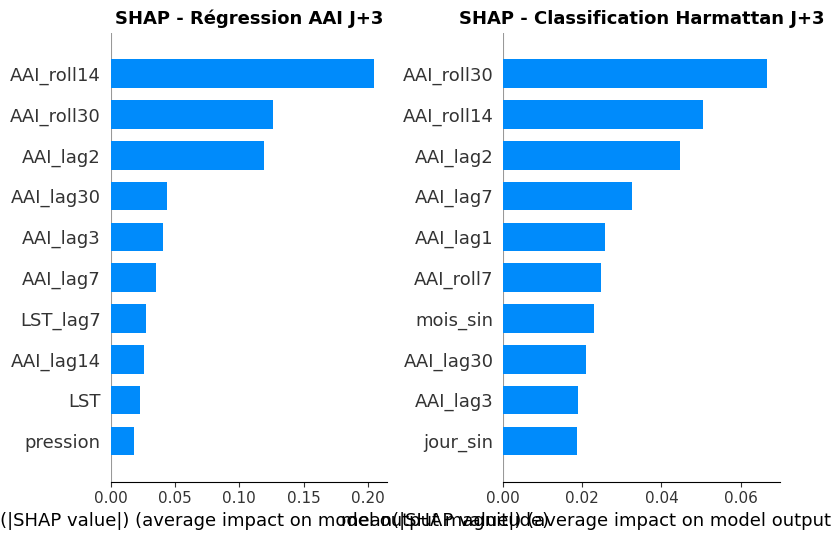

Graphiques SHAP sauvegardés !


In [25]:
print("Calcul SHAP Régression...")
explainer_reg   = shap.TreeExplainer(rf_reg)
shap_values_reg = explainer_reg.shap_values(X_test_clean)

print("Calcul SHAP Classification...")
explainer_clf   = shap.TreeExplainer(rf_clf_smote)
shap_values_clf = explainer_clf.shap_values(X_test_clean)

shap_imp_reg = pd.DataFrame({
    'Feature'    : X_test_clean.columns,
    'Importance' : np.abs(shap_values_reg).mean(0)
}).sort_values('Importance', ascending=False)

shap_imp_clf = pd.DataFrame({
    'Feature'    : X_test_clean.columns,
    'Importance' : np.abs(shap_values_clf[:,:,1]).mean(0)
}).sort_values('Importance', ascending=False)

print("\nTop 10 SHAP Régression :")
print(shap_imp_reg.head(10).to_string(index=False))

print("\nTop 10 SHAP Classification :")
print(shap_imp_clf.head(10).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

plt.sca(axes[0])
shap.summary_plot(shap_values_reg, X_test_clean,
                  max_display=10, show=False, plot_type='bar')
axes[0].set_title('SHAP - Régression AAI J+3', fontsize=13, fontweight='bold')

plt.sca(axes[1])
shap.summary_plot(shap_values_clf[:,:,1], X_test_clean,
                  max_display=10, show=False, plot_type='bar')
axes[1].set_title('SHAP - Classification Harmattan J+3', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Ouaga_Grid/shap_final.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Graphiques SHAP sauvegardés !")

## 8. Sauvegarde des Modèles

Sauvegarde pour utilisation dans le dashboard Streamlit.

In [26]:
save_dir = '/content/drive/MyDrive/Ouaga_Grid/models/'
os.makedirs(save_dir, exist_ok=True)

joblib.dump(rf_reg, save_dir + 'rf_regression.pkl')
joblib.dump(rf_clf_smote, save_dir + 'rf_classification.pkl')

config = {
    'features'      : list(X_train_clean.columns),
    'seuil_optimal' : float(meilleur_seuil),
    'metriques'     : {
        'regression'     : resultats_reg['RF'],
        'classification' : {
            'F1'     : float(meilleur_f1),
            'AUC_ROC': float(roc_auc_score(y_clf_test_clean, y_proba_smote)),
            'Recall' : float(recall_score(y_clf_test_clean, y_pred_final,
                             pos_label=1, zero_division=0))
        }
    }
}

with open(save_dir + 'config.json', 'w') as f:
    json.dump(config, f, indent=2)

print("Modèles sauvegardés !")
print(f"Fichiers : {os.listdir(save_dir)}")

Modèles sauvegardés !
Fichiers : ['config.json', 'rf_regression.pkl', 'rf_classification.pkl']


## 9. Visualisations des Résultats

Visualisations complètes pour interpréter et présenter
les performances des modèles :
- Évolution AAI 2018-2025
- Prédictions vs Réalité
- Matrice de confusion
- Courbe ROC

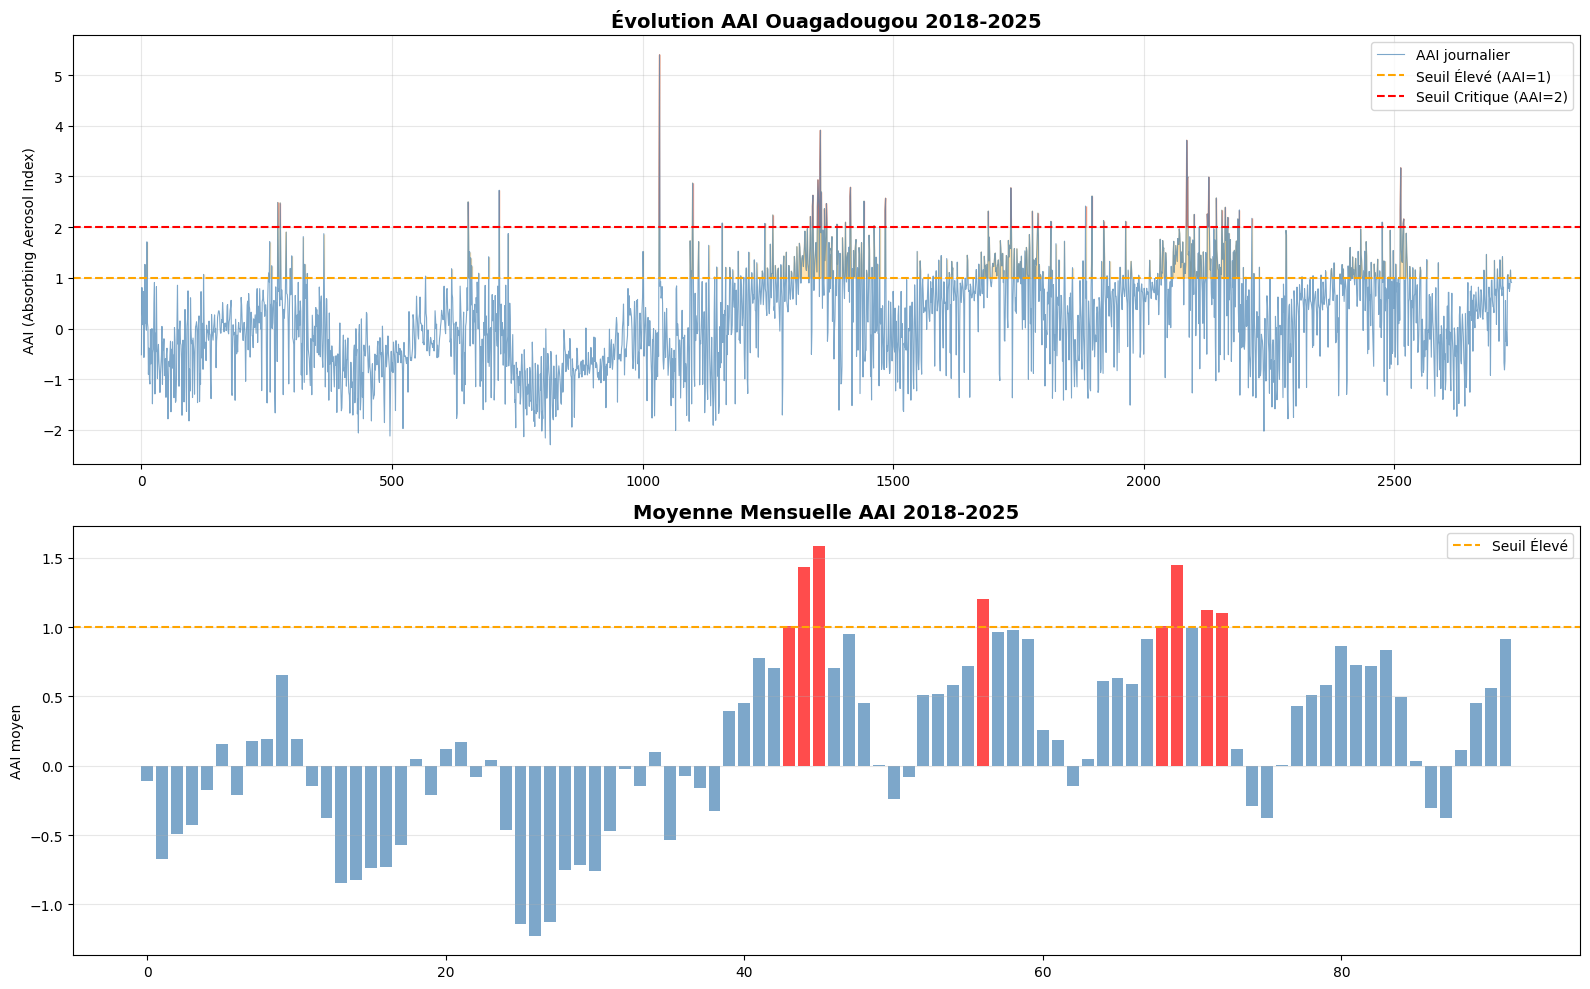

Graphique sauvegardé !


In [27]:
#Evolution AAI 2018-2025
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Graph 1 : Evolution AAI journalier
axes[0].plot(df.index, df['AAI'], color='steelblue',
             linewidth=0.8, alpha=0.7, label='AAI journalier')
axes[0].axhline(y=1, color='orange', linestyle='--',
                linewidth=1.5, label='Seuil Élevé (AAI=1)')
axes[0].axhline(y=2, color='red', linestyle='--',
                linewidth=1.5, label='Seuil Critique (AAI=2)')
axes[0].fill_between(df.index, df['AAI'], 1,
                     where=(df['AAI'] >= 1),
                     color='orange', alpha=0.3)
axes[0].fill_between(df.index, df['AAI'], 2,
                     where=(df['AAI'] >= 2),
                     color='red', alpha=0.3)
axes[0].set_title('Évolution AAI Ouagadougou 2018-2025',
                   fontsize=14, fontweight='bold')
axes[0].set_ylabel('AAI (Absorbing Aerosol Index)')
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)

# Graph 2 : Moyenne mensuelle AAI
df_monthly = df.copy()
df_monthly['mois_num'] = pd.to_datetime(
    df_monthly.index.astype(str), errors='coerce'
)
aai_mensuel = df['AAI'].groupby(
    df.index // 30
).mean()

axes[1].bar(range(len(aai_mensuel)), aai_mensuel,
            color=['red' if v >= 1 else 'steelblue'
                   for v in aai_mensuel],
            alpha=0.7)
axes[1].axhline(y=1, color='orange', linestyle='--',
                linewidth=1.5, label='Seuil Élevé')
axes[1].set_title('Moyenne Mensuelle AAI 2018-2025',
                   fontsize=14, fontweight='bold')
axes[1].set_ylabel('AAI moyen')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Ouaga_Grid/evolution_aai.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Graphique sauvegardé !")

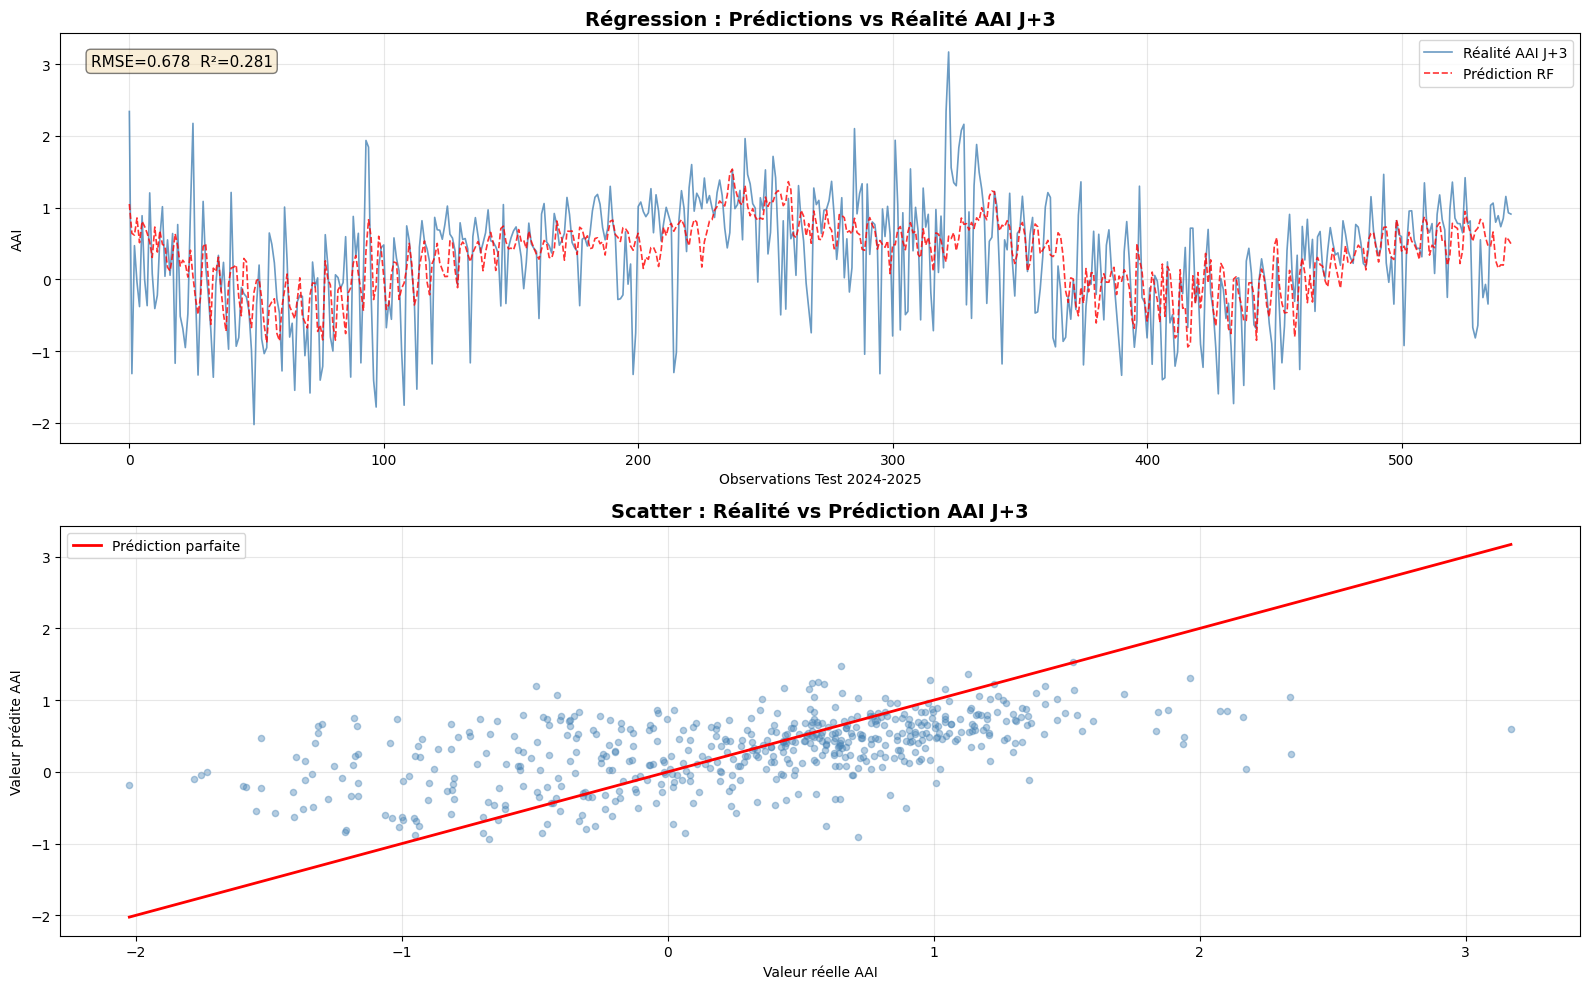

Graphique sauvegardé !


In [28]:
#Prédictions vs Réalité
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

axes[0].plot(range(len(y_reg_test_clean)),
             y_reg_test_clean.values,
             color='steelblue', linewidth=1.2,
             label='Réalité AAI J+3', alpha=0.8)
axes[0].plot(range(len(y_pred_reg)),
             y_pred_reg,
             color='red', linewidth=1.2,
             label='Prédiction RF', alpha=0.8,
             linestyle='--')
axes[0].set_title('Régression : Prédictions vs Réalité AAI J+3',
                   fontsize=14, fontweight='bold')
axes[0].set_ylabel('AAI')
axes[0].set_xlabel('Observations Test 2024-2025')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

rmse = np.sqrt(mean_squared_error(y_reg_test_clean, y_pred_reg))
r2   = r2_score(y_reg_test_clean, y_pred_reg)
axes[0].text(0.02, 0.95, f'RMSE={rmse:.3f}  R²={r2:.3f}',
             transform=axes[0].transAxes,
             fontsize=11, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

axes[1].scatter(y_reg_test_clean, y_pred_reg,
                alpha=0.4, color='steelblue', s=20)
axes[1].plot([y_reg_test_clean.min(), y_reg_test_clean.max()],
             [y_reg_test_clean.min(), y_reg_test_clean.max()],
             color='red', linewidth=2, label='Prédiction parfaite')
axes[1].set_title('Scatter : Réalité vs Prédiction AAI J+3',
                   fontsize=14, fontweight='bold')
axes[1].set_xlabel('Valeur réelle AAI')
axes[1].set_ylabel('Valeur prédite AAI')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Ouaga_Grid/predictions_vs_realite.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Graphique sauvegardé !")

## 10. Visualisations des Résultats

### 10.2 Matrice de Confusion et Courbe ROC

- **Matrice de confusion** : montre les vrais/faux positifs et négatifs
- **Courbe ROC** : mesure le pouvoir discriminant du modèle

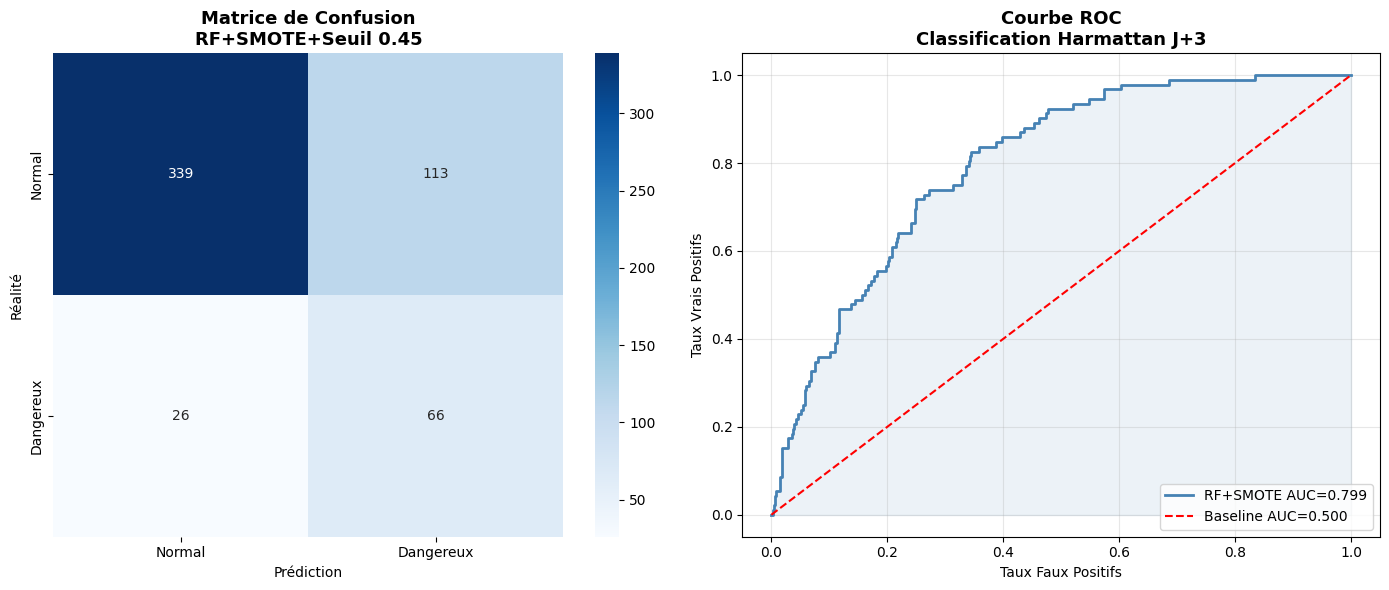

Graphique sauvegardé !


In [31]:
# Matrice de confusion et courbe ROC
# Evaluation complète du modèle de classification

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Matrice de confusion
cm = confusion_matrix(y_clf_test_clean, y_pred_clf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal','Dangereux'],
            yticklabels=['Normal','Dangereux'],
            ax=axes[0])
axes[0].set_title('Matrice de Confusion\nRF+SMOTE+Seuil 0.45',
                   fontsize=13, fontweight='bold')
axes[0].set_ylabel('Réalité')
axes[0].set_xlabel('Prédiction')

# Courbe ROC
fpr, tpr, _ = roc_curve(y_clf_test_clean, y_proba_clf)
auc_score   = roc_auc_score(y_clf_test_clean, y_proba_clf)

axes[1].plot(fpr, tpr, color='steelblue', linewidth=2,
             label=f'RF+SMOTE AUC={auc_score:.3f}')
axes[1].plot([0,1], [0,1], color='red', linestyle='--',
             linewidth=1.5, label='Baseline AUC=0.500')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='steelblue')
axes[1].set_title('Courbe ROC\nClassification Harmattan J+3',
                   fontsize=13, fontweight='bold')
axes[1].set_xlabel('Taux Faux Positifs')
axes[1].set_ylabel('Taux Vrais Positifs')
axes[1].legend(loc='lower right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Ouaga_Grid/confusion_roc.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Graphique sauvegardé !")